# Model Explainability

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.inspection import PartialDependenceDisplay
import shap

RANDOM_STATE = 42

shap.initjs()
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')
df.columns = df.columns.str.lower()
df = df.drop(columns=['customer_id', 'surname'], errors='ignore')
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
#Model Alignment
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)

tunned_catboost = CatBoostClassifier(
    depth=5, 
    iterations=200, 
    l2_leaf_reg=9,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    verbose=0
    )
tunned_catboost.fit(X_train, y_train)

/Users/java/Desktop/Aliya's project/Churn-Prediction-Bank-Customer-Retention-Strategy/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CatBoostClassifier(depth=5, iterations=200, l2_leaf_reg=9, learning_rate=0.05, random_state=42, verbose=0)

### Interpret Logistical Regression Coefficients
The ones that we found above

/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_9919/2156925152.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='muted')


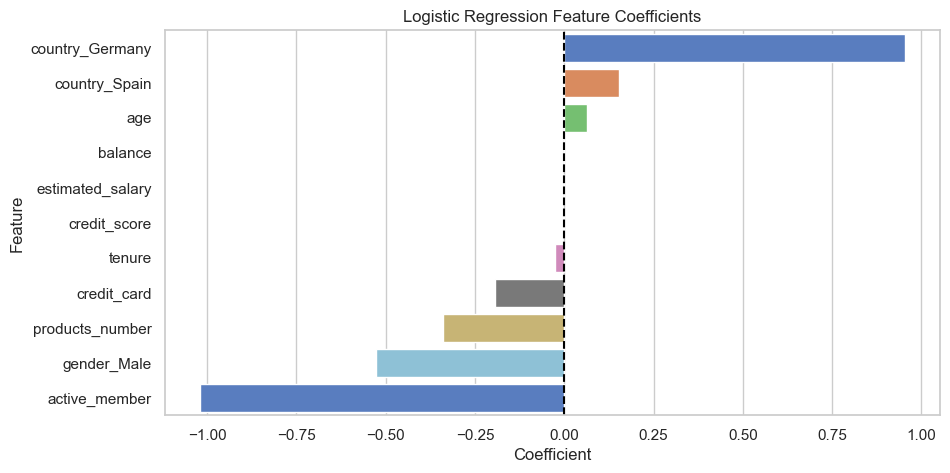

In [8]:
coef = lr_model.coef_[0] #coef = coefficients
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
}).sort_values(by='Coefficient', ascending = False)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='muted')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Logistic Regression Feature Coefficients')
plt.show()

### BarChart (Treemodels) ranking the Importance of Global Features

/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_9919/3530347253.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='muted')


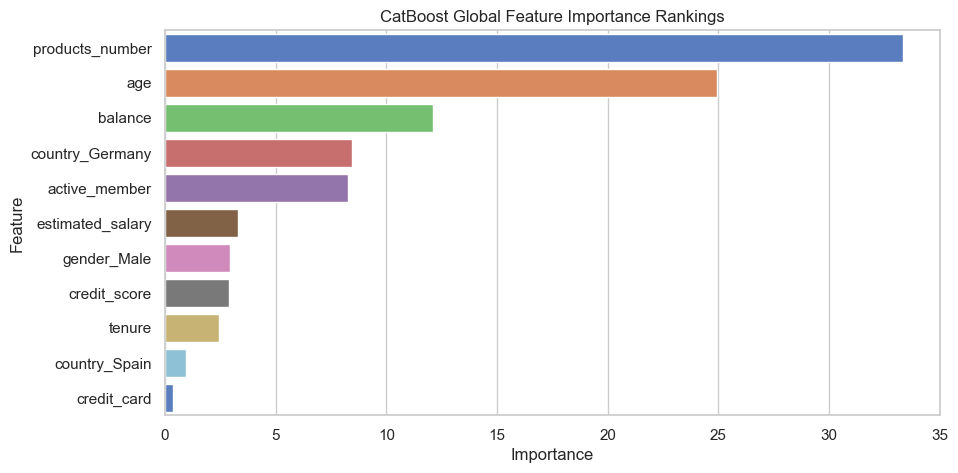

In [9]:
cat_importances = tunned_catboost.get_feature_importance()


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': cat_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='muted')
plt.title('CatBoost Global Feature Importance Rankings')
plt.show()

Because I used CatBoost I visualized feature importance in the form of a barplot rather than a tree model. As CatBoost uses an ensemble tree model, and not just a single decision tree here. So the barplot looks over the trees and showcases the important features in the graph above.

### SHAP Global Explainability

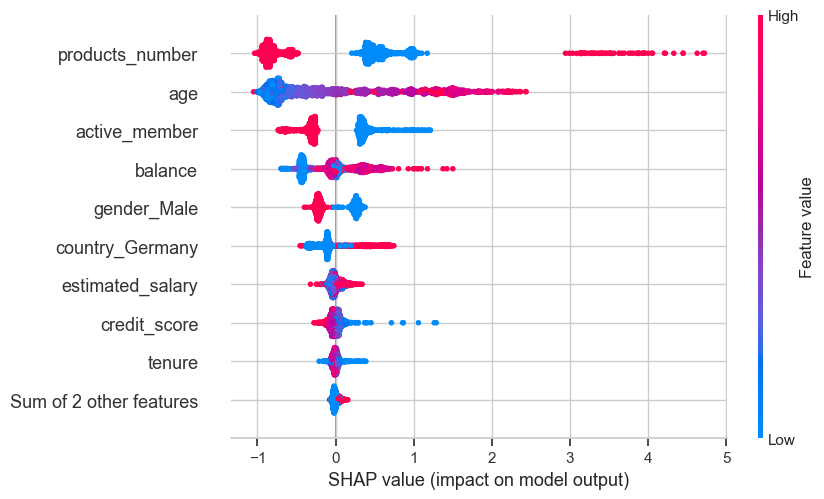

In [10]:
explainer = shap.TreeExplainer(tunned_catboost)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10)

### SHAP Local Explainability

A Local audit Report for the high-risk Client: 8


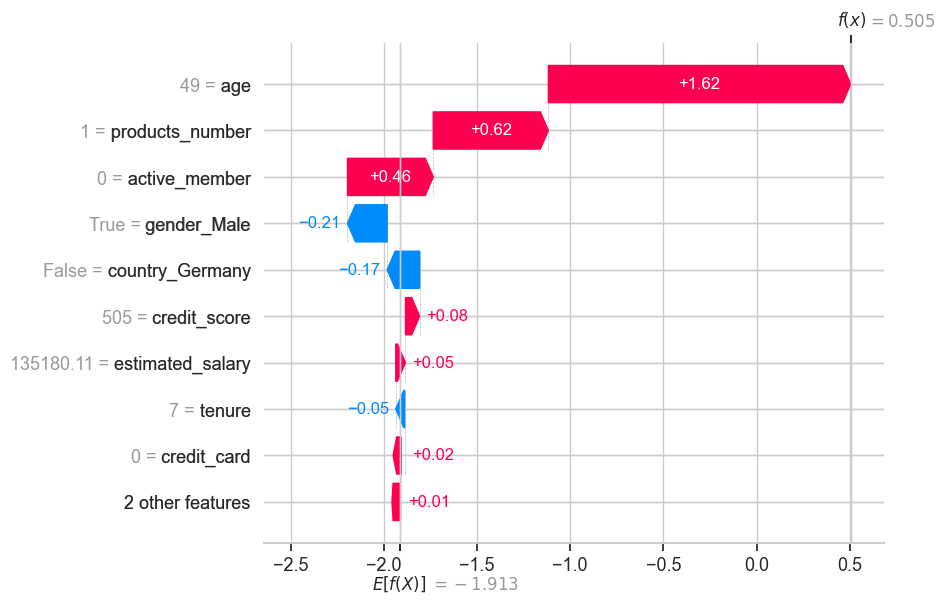

In [11]:
high_risk_index = np.where(tunned_catboost.predict(X_test) == 1)[0][0]

print(f"A Local audit Report for the high-risk Client: {high_risk_index}")
shap.plots.waterfall(shap_values[high_risk_index])

### Partial Dependence Plots (PDPs)

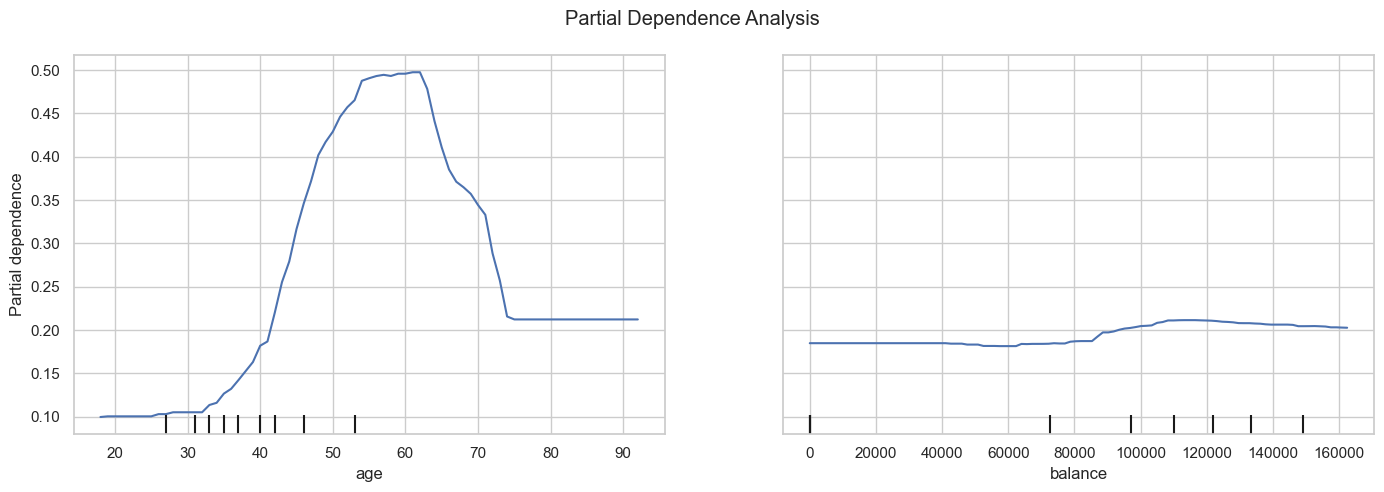

In [12]:
features_to_plot = ['age', 'balance']
fig, ax = plt.subplots(figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    tunned_catboost, 
    X_train, 
    features_to_plot,
    ax=ax
)
plt.suptitle('Partial Dependence Analysis')
plt.tight_layout()
plt.show()